# Property Price Prediction Project

**Course:** Data Science with GenAI  
**Topic:** Supervised Learning – Regression Mini Project  
**Dataset:** `property_price_data.csv`  
**Target variable:** `SalePrice`

In this project, I am working on property price data.  
The main aim is to understand the data and build a model that can predict the sale price of a property.

## Import Libraries

First, I imported the required Python libraries.  
These libraries will help me in data cleaning, visualization, and model building.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Utility
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

## Load Dataset

Here, I loaded the CSV file into a pandas dataframe.  
After loading the data, I checked the shape and first few rows to understand how the data looks.

In [22]:
import pandas as pd

df = pd.read_csv("property_price_data.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (970, 69)


,Prop_Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,PropStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,YrSold,SaleCondition,SalePrice
0,PRO504,20,RL,100.0,15537,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,1Story,7,8,1959,1997,Gable,CompShg,BrkFace,Wd Sdng,TA,TA,CBlock,TA,TA,No,1501,GasA,TA,Y,SBrkr,1801,1,0,2,0,1,1,TA,6,Typ,2,TA,Attchd,1959.0,Fin,2,484,TA,TA,Y,0,54,0,0,161,0,NaN,GdWo,NaN,0,2010,Normal,288330
1,PRO102,60,RL,77.0,9534,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,SawyerW,Norm,Norm,1Fam,2Story,6,5,1985,1985,Gable,CompShg,HdBoard,HdBoard,Gd,TA,CBlock,Gd,TA,No,741,GasA,TA,Y,SBrkr,1732,0,0,2,1,3,1,Gd,7,Typ,1,TA,Attchd,1985.0,Fin,2,476,TA,TA,Y,192,46,0,0,0,0,NaN,NaN,NaN,0,2010,Normal,183164
2,PRO609,70,RL,NaN,12781,Pave,NaN,Reg,HLS,AllPub,Inside,Mod,Crawfor,Norm,Norm,1Fam,2Story,8,6,1934,1998,Gable,CompShg,BrkFace,Wd Sdng,TA,TA,PConc,Gd,TA,Mn,987,GasA,TA,Y,SBrkr,3194,0,0,2,1,4,1,TA,10,Typ,2,Gd,Basment,1934.0,Unf,2,380,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,2007,Alloca,362145
3,PRO1090,120,FV,37.0,3728,Pave,Pave,IR1,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,TwnhsE,1Story,8,5,2005,2005,Gable,CompShg,MetalSd,MetalSd,Gd,TA,PConc,Gd,TA,No,1247,GasA,Ex,Y,SBrkr,1247,1,0,1,1,1,1,Gd,4,Typ,1,Gd,Attchd,2005.0,Fin,2,550,TA,TA,Y,0,84,0,0,0,0,NaN,NaN,NaN,0,2006,Normal,196079
4,PRO820,120,RL,44.0,6606,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,TwnhsE,1Story,7,5,2009,2010,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,Gd,TA,Mn,1358,GasA,Ex,Y,SBrkr,1358,1,0,2,0,2,1,Gd,6,Typ,1,Gd,Attchd,2010.0,RFn,2,484,TA,TA,Y,192,35,0,0,0,0,NaN,NaN,NaN,0,2010,Partial,228515


## Dataset Overview

In this step, I checked the basic information about the dataset.  
I looked at the number of rows, columns, data types, and summary statistics.

In [23]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("\nNumeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

display(df.info())
display(df.describe().T)

Rows: 970
Columns: 69

Numeric columns: 29
Categorical columns: 40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 69 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Prop_Id        970 non-null    object 
 1   MSSubClass     970 non-null    int64  
 2   MSZoning       970 non-null    object 
 3   LotFrontage    789 non-null    float64
 4   LotArea        970 non-null    int64  
 5   Street         970 non-null    object 
 6   Alley          56 non-null     object 
 7   LotShape       970 non-null    object 
 8   LandContour    970 non-null    object 
 9   Utilities      970 non-null    object 
 10  LotConfig      970 non-null    object 
 11  LandSlope      970 non-null    object 
 12  Neighborhood   970 non-null    object 
 13  Condition1     970 non-null    object 
 14  Condition2     970 non-null    object 
 15  BldgType       970 non-null    object 
 16  PropStyle      970 non-null    

None

,count,mean,std,min,25%,50%,75%,max
MSSubClass,970.0,58.092784,42.962071,20.0,20.00,50.0,70.00,190.0
LotFrontage,789.0,69.447402,24.139429,21.0,57.00,68.0,80.00,313.0
LotArea,970.0,11208.956701,10153.538896,1663.0,8147.50,10174.5,12482.25,216301.0
OverallQual,970.0,6.143299,1.396990,1.0,5.00,6.0,7.00,10.0
OverallCond,970.0,5.547423,1.091443,1.0,5.00,5.0,6.00,9.0
YearBuilt,970.0,1971.496907,30.247798,1875.0,1954.00,1974.0,2000.00,2009.0
YearRemodAdd,970.0,1984.741237,20.659310,1950.0,1966.25,1994.0,2004.00,2010.0
TotalBsmtSF,970.0,1079.728866,463.970814,0.0,808.00,1008.0,1324.00,6110.0
GrLivArea,970.0,1532.874227,546.642210,438.0,1141.75,1469.0,1792.00,5642.0
BsmtFullBath,970.0,0.437113,0.518655,0.0,0.00,0.0,1.00,3.0


## 4. Missing Value Analysis

Here, I checked missing values in the dataset.  
This step is important because missing values can affect the model performance.

,missing_count,missing_percent
PoolQC,963,99.28
MiscFeature,941,97.01
Alley,914,94.23
Fence,801,82.58
FireplaceQu,437,45.05
LotFrontage,181,18.66
GarageType,52,5.36
GarageYrBlt,52,5.36
GarageFinish,52,5.36
GarageQual,52,5.36


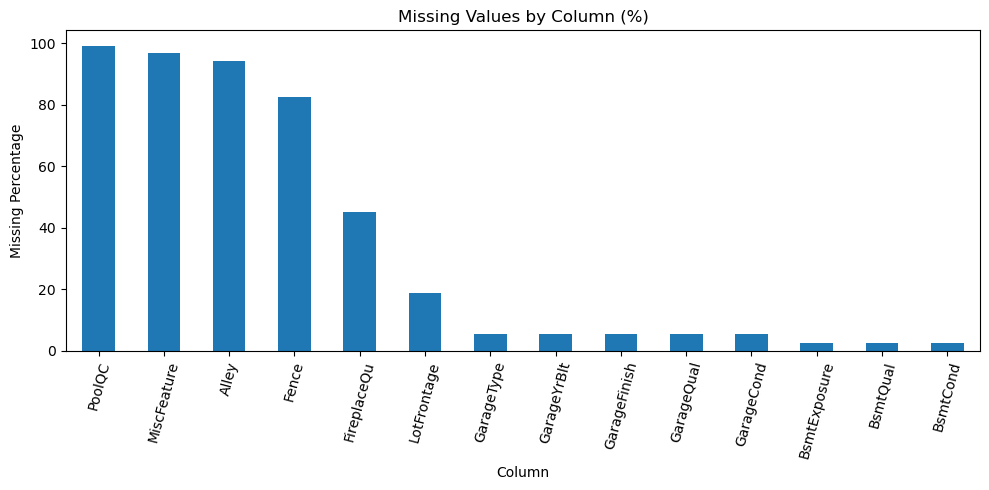

In [4]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().sum() / len(df) * 100).round(2)
}).query("missing_count > 0").sort_values("missing_percent", ascending=False)

display(missing_summary)

plt.figure(figsize=(10, 5))
missing_summary["missing_percent"].plot(kind="bar")
plt.title("Missing Values by Column (%)")
plt.ylabel("Missing Percentage")
plt.xlabel("Column")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

## Target Variable Analysis

In this section, I analyzed the SalePrice column.  
SalePrice is the target variable because this is what we want to predict.

,SalePrice
count,970.000000
mean,184272.595876
std,82061.647461
min,35336.000000
25%,132225.000000
50%,165641.500000
75%,215268.250000
max,758639.000000


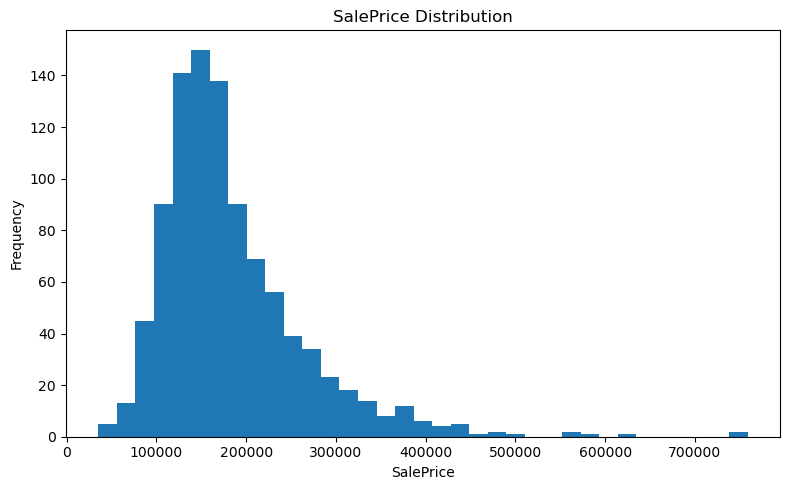

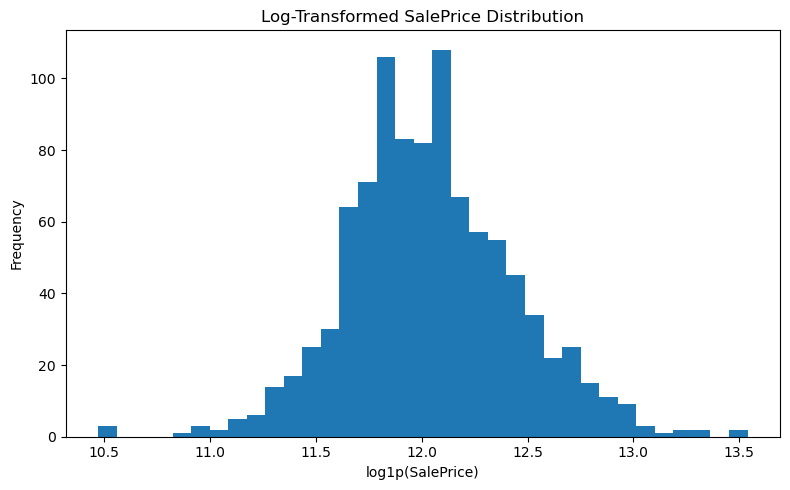

Skewness before log transformation: 1.976
Skewness after log transformation: 0.175


In [5]:
target = "SalePrice"

display(df[target].describe().to_frame())

plt.figure(figsize=(8, 5))
plt.hist(df[target], bins=35)
plt.title("SalePrice Distribution")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(df[target]), bins=35)
plt.title("Log-Transformed SalePrice Distribution")
plt.xlabel("log1p(SalePrice)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Skewness before log transformation:", round(df[target].skew(), 3))
print("Skewness after log transformation:", round(np.log1p(df[target]).skew(), 3))

## 6. Correlation Analysis

Here, I checked the relationship between numerical features and SalePrice.  
This helped me understand which features are more related to property price.

,correlation_with_saleprice
SalePrice,1.000000
OverallQual,0.787500
GrLivArea,0.705701
GarageCars,0.642999
GarageArea,0.619476
TotalBsmtSF,0.597116
FullBath,0.574070
TotRmsAbvGrd,0.520046
YearBuilt,0.511482
YearRemodAdd,0.486579


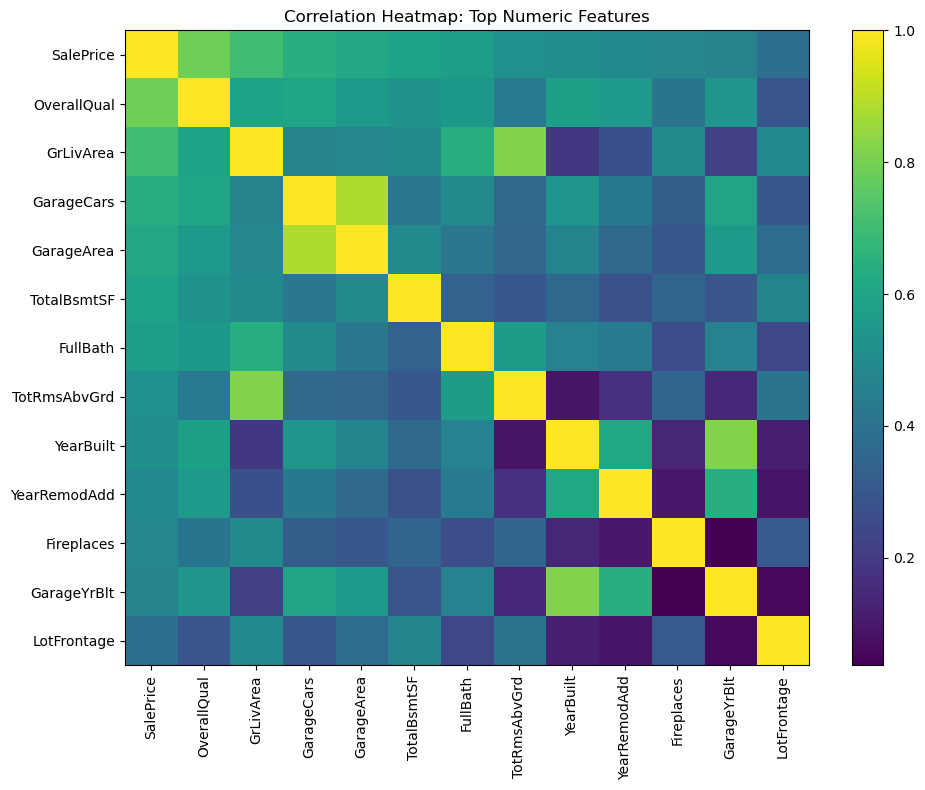

In [6]:
corr_matrix = df.select_dtypes(include=np.number).corr(numeric_only=True)

saleprice_corr = corr_matrix[target].sort_values(ascending=False)
display(saleprice_corr.head(15).to_frame("correlation_with_saleprice"))

top_corr_features = saleprice_corr.drop(target).abs().sort_values(ascending=False).head(12).index.tolist()

plt.figure(figsize=(10, 8))
corr_subset = df[[target] + top_corr_features].corr(numeric_only=True)
plt.imshow(corr_subset, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_subset.columns)), corr_subset.columns, rotation=90)
plt.yticks(range(len(corr_subset.columns)), corr_subset.columns)
plt.title("Correlation Heatmap: Top Numeric Features")
plt.tight_layout()
plt.show()

## Data Preprocessing

In this step, I cleaned the data before building the model.  
I handled missing values, checked outliers, and corrected data types where needed.

In [7]:
data = df.copy()

# Convert MSSubClass to string because it is a category code, not a true continuous numeric variable.
data["MSSubClass"] = data["MSSubClass"].astype(str)

# Columns where missing values usually mean the feature is absent.
none_value_cols = [
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "PoolQC", "Fence", "MiscFeature"
]

for col in none_value_cols:
    if col in data.columns:
        data[col] = data[col].fillna("None")

# LotFrontage: neighborhood-level median imputation.
if "LotFrontage" in data.columns:
    data["LotFrontage"] = data.groupby("Neighborhood")["LotFrontage"].transform(
        lambda s: s.fillna(s.median())
    )
    data["LotFrontage"] = data["LotFrontage"].fillna(data["LotFrontage"].median())

# Garage year: use construction year when garage year is missing.
if "GarageYrBlt" in data.columns:
    data["GarageYrBlt"] = data["GarageYrBlt"].fillna(data["YearBuilt"])

remaining_missing = data.isna().sum().sum()
print("Remaining missing values:", remaining_missing)

if remaining_missing > 0:
    display(data.isna().sum()[data.isna().sum() > 0])
else:
    print("All missing values have been treated.")

Remaining missing values: 0
All missing values have been treated.


In [8]:
continuous_cols = [
    "LotFrontage", "LotArea", "TotalBsmtSF", "GrLivArea", "GarageArea",
    "WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch",
    "ScreenPorch", "PoolArea", "MiscVal"
]

outlier_report = []

for col in continuous_cols:
    if col in data.columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower_iqr = q1 - 1.5 * iqr
        upper_iqr = q3 + 1.5 * iqr
        outlier_count = ((data[col] < lower_iqr) | (data[col] > upper_iqr)).sum()

        lower_cap = data[col].quantile(0.01)
        upper_cap = data[col].quantile(0.99)
        data[col] = data[col].clip(lower_cap, upper_cap)

        outlier_report.append({
            "feature": col,
            "iqr_outlier_count": int(outlier_count),
            "lower_cap_1pct": round(lower_cap, 2),
            "upper_cap_99pct": round(upper_cap, 2)
        })

outlier_report_df = pd.DataFrame(outlier_report)
display(outlier_report_df.sort_values("iqr_outlier_count", ascending=False))

,feature,iqr_outlier_count,lower_cap_1pct,upper_cap_99pct
7,EnclosedPorch,138,0.00,252.62
9,ScreenPorch,81,0.00,279.72
0,LotFrontage,65,21.00,138.62
6,OpenPorchSF,52,0.00,288.24
1,LotArea,43,2233.97,37560.63
2,TotalBsmtSF,42,0.00,2218.86
11,MiscVal,27,0.00,731.00
3,GrLivArea,25,693.07,3204.54
5,WoodDeckSF,20,0.00,496.55
8,3SsnPorch,20,0.00,180.00


In [9]:
# Convert year columns to integer after missing treatment.
year_cols = ["YearBuilt", "YearRemodAdd", "GarageYrBlt", "YrSold"]
for col in year_cols:
    if col in data.columns:
        data[col] = data[col].astype(int)

# Convert binary yes/no fields to category-like object type.
for col in ["CentralAir"]:
    if col in data.columns:
        data[col] = data[col].astype(str)

print(data[["MSSubClass", "YearBuilt", "YearRemodAdd", "GarageYrBlt", "YrSold"]].dtypes)

MSSubClass      object
YearBuilt        int64
YearRemodAdd     int64
GarageYrBlt      int64
YrSold           int64
dtype: object


In [10]:
print("Duplicate rows:", data.duplicated().sum())

if "Prop_Id" in data.columns:
    print("Duplicate property IDs:", data["Prop_Id"].duplicated().sum())

validation_checks = {
    "negative_saleprice": int((data["SalePrice"] <= 0).sum()),
    "negative_lotarea": int((data["LotArea"] <= 0).sum()),
    "yearbuilt_after_yrsold": int((data["YearBuilt"] > data["YrSold"]).sum()),
    "yearremod_after_yrsold": int((data["YearRemodAdd"] > data["YrSold"]).sum())
}

display(pd.Series(validation_checks, name="count").to_frame())

Duplicate rows: 0
Duplicate property IDs: 0


,count
negative_saleprice,0
negative_lotarea,0
yearbuilt_after_yrsold,0
yearremod_after_yrsold,1


## Feature Engineering

Here, I created useful features and prepared the data for machine learning.  
I also applied log transformation on SalePrice because the price values were not normally distributed.

## Create New Features

New features are created to improve model interpretability and predictive power:

- `PropertyAge`
- `RemodelAge`
- `GarageAge`
- `TotalSF`
- `TotalBath`
- `PorchSF`
- `HasGarage`
- `HasBasement`
- `HasPool`
- `HasFireplace`
- `IsRemodeled`

In [11]:
# Use year sold as the reference point for age features.
data["PropertyAge"] = (data["YrSold"] - data["YearBuilt"]).clip(lower=0)
data["RemodelAge"] = (data["YrSold"] - data["YearRemodAdd"]).clip(lower=0)
data["GarageAge"] = (data["YrSold"] - data["GarageYrBlt"]).clip(lower=0)

data["TotalSF"] = data["TotalBsmtSF"] + data["GrLivArea"]

data["TotalBath"] = (
    data["FullBath"]
    + 0.5 * data["HalfBath"]
    + data["BsmtFullBath"]
    + 0.5 * data["BsmtHalfBath"]
)

data["PorchSF"] = (
    data["WoodDeckSF"]
    + data["OpenPorchSF"]
    + data["EnclosedPorch"]
    + data["3SsnPorch"]
    + data["ScreenPorch"]
)

data["HasGarage"] = (data["GarageArea"] > 0).astype(int)
data["HasBasement"] = (data["TotalBsmtSF"] > 0).astype(int)
data["HasPool"] = (data["PoolArea"] > 0).astype(int)
data["HasFireplace"] = (data["Fireplaces"] > 0).astype(int)
data["IsRemodeled"] = (data["YearRemodAdd"] != data["YearBuilt"]).astype(int)

# Cap newly created area features too.
for col in ["TotalSF", "PorchSF"]:
    lower_cap = data[col].quantile(0.01)
    upper_cap = data[col].quantile(0.99)
    data[col] = data[col].clip(lower_cap, upper_cap)

new_features = [
    "PropertyAge", "RemodelAge", "GarageAge", "TotalSF", "TotalBath",
    "PorchSF", "HasGarage", "HasBasement", "HasPool", "HasFireplace", "IsRemodeled"
]

display(data[new_features].head())

,PropertyAge,RemodelAge,GarageAge,TotalSF,TotalBath,PorchSF,HasGarage,HasBasement,HasPool,HasFireplace,IsRemodeled
0,51,13,51,3302.0,3.0,215.0,1,1,0,1,1
1,25,25,25,2473.0,2.5,238.0,1,1,0,1,0
2,73,9,73,4181.0,2.5,0.0,1,1,0,1,1
3,1,1,1,2494.0,2.5,84.0,1,1,0,1,0
4,1,0,0,2716.0,3.0,227.0,1,1,0,1,1


## Target Variable Transformation

We apply `log1p()` to `SalePrice` because property prices are right-skewed.  
This helps the models learn relative percentage differences more effectively.

In [12]:
data["LogSalePrice"] = np.log1p(data["SalePrice"])

print("Original SalePrice skew:", round(data["SalePrice"].skew(), 3))
print("LogSalePrice skew:", round(data["LogSalePrice"].skew(), 3))

Original SalePrice skew: 1.976
LogSalePrice skew: 0.175


## Encoding Categorical Columns

Machine learning models cannot directly understand text values.  
So, I converted categorical columns into numerical form using dummy variables.

In [13]:
# Drop ID and keep target separately.
X = data.drop(columns=["Prop_Id", "SalePrice", "LogSalePrice"])
y_log = data["LogSalePrice"]

categorical_cols_after = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols_after = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Numeric feature count before encoding:", len(numeric_cols_after))
print("Categorical feature count before encoding:", len(categorical_cols_after))

X_encoded = pd.get_dummies(X, columns=categorical_cols_after, drop_first=True)

print("Final feature count after dummy encoding:", X_encoded.shape[1])
display(X_encoded.head())

Numeric feature count before encoding: 38
Categorical feature count before encoding: 40
Final feature count after dummy encoding: 246


,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold,PropertyAge,RemodelAge,GarageAge,TotalSF,TotalBath,PorchSF,HasGarage,HasBasement,HasPool,HasFireplace,IsRemodeled,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_None,Alley_Pave,LotShape_IR2,...,Heating_Wall,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_TA,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_None,FireplaceQu_Po,FireplaceQu_TA,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Fa,GarageQual_Gd,GarageQual_None,GarageQual_Po,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_None,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y,PoolQC_Fa,PoolQC_Gd,PoolQC_None,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_None,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,100.0,15537.0,7,8,1959,1997,1501.0,1801.0,1,0,2,0,1,1,6,2,1959,2,484,0.0,54.0,0.0,0,161.0,0,0,2010,51,13,51,3302.0,3.0,215.0,1,1,0,1,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False,...,False,False,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,True,True,False,False,False,True,False,False,False,False,False,False,True,False
1,77.0,9534.0,6,5,1985,1985,741.0,1732.0,0,0,2,1,3,1,7,1,1985,2,476,192.0,46.0,0.0,0,0.0,0,0,2010,25,25,25,2473.0,2.5,238.0,1,1,0,1,0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,True,False,False,...,False,False,False,True,True,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,True,True,False,False,False,False,False,False,True,False
2,64.0,12781.0,8,6,1934,1998,987.0,3194.0,0,0,2,1,4,1,10,2,1934,2,380,0.0,0.0,0.0,0,0.0,0,0,2007,73,9,73,4181.0,2.5,0.0,1,1,0,1,1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,True,False,False,...,False,False,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False
3,37.0,3728.0,8,5,2005,2005,1247.0,1247.0,1,0,1,1,1,1,4,1,2005,2,550,0.0,84.0,0.0,0,0.0,0,0,2006,1,1,1,2494.0,2.5,84.0,1,1,0,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,...,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,F

## Feature Selection Strategy

The feature selection strategy combines:

1. Domain-based features such as total square footage, property age, total bathrooms, and garage indicators.
2. Correlation analysis with `SalePrice`.
3. Model-based importance after fitting tree-based models.

We keep the full encoded feature set for model comparison, but later use model importance to identify the most influential predictors.

In [14]:
# Top numeric/engineered features by correlation with target.
feature_corr = pd.concat([X_encoded, data["SalePrice"]], axis=1).corr(numeric_only=True)["SalePrice"]
top_feature_corr = feature_corr.drop("SalePrice").abs().sort_values(ascending=False).head(20)

display(top_feature_corr.to_frame("absolute_correlation_with_saleprice"))

,absolute_correlation_with_saleprice
TotalSF,0.795036
OverallQual,0.787500
GrLivArea,0.713822
GarageCars,0.642999
TotalBsmtSF,0.634873
TotalBath,0.633412
GarageArea,0.630801
ExterQual_TA,0.584636
FullBath,0.574070
KitchenQual_TA,0.522703


## Train-Test Split

In this step, I divided the data into training and testing parts.  
The training data is used to train the model, and the testing data is used to check model performance.

In [15]:
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X_encoded,
    y_log,
    test_size=0.20,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (776, 246)
Testing shape: (194, 246)


## Model Building

Here, I trained different regression models to predict property prices.  
I compared the models to find which one gives better results.

## Model Selection and Justification

We compare four regression approaches:

- **Ridge Regression:** Good baseline for many numeric and dummy variables; reduces overfitting using L2 regularization.
- **Lasso Regression:** Useful for feature selection because it can shrink weak coefficients to zero.
- **Random Forest Regressor:** Captures non-linear relationships and interactions between housing features.
- **Gradient Boosting Regressor:** Often performs well on tabular regression problems by combining many weak learners.

The target is modeled on the log scale. Final predictions are converted back to the original price scale using `expm1()`.

## Model Training and Parameter Tuning

The parameter search below is intentionally compact so it can run quickly in a classroom/Jupyter environment while still demonstrating tuning.

In [16]:
def evaluate_predictions(y_true_log, y_pred_log):
    """Return RMSE, MAE, R2, and RMSLE using original and log price scales."""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmsle = mean_squared_error(y_true_log, y_pred_log) ** 0.5

    return rmse, mae, r2, rmsle


def tune_with_cv(model_candidates, X_train_input, y_train_input, scaled=False):
    """Perform compact cross-validation tuning for a list of model candidates."""
    cv = KFold(n_splits=3, shuffle=True, random_state=42)
    tuning_rows = []

    for model_name, model in model_candidates:
        cv_scores = cross_val_score(
            model,
            X_train_input,
            y_train_input,
            cv=cv,
            scoring="neg_root_mean_squared_error"
        )
        tuning_rows.append({
            "model_candidate": model_name,
            "mean_cv_rmsle": -cv_scores.mean(),
            "std_cv_rmsle": cv_scores.std(),
            "scaled_input": scaled,
            "model_object": model
        })

    return pd.DataFrame(tuning_rows)


ridge_candidates = [
    (f"Ridge_alpha_{alpha}", Ridge(alpha=alpha))
    for alpha in [1, 10, 50]
]

lasso_candidates = [
    (f"Lasso_alpha_{alpha}", Lasso(alpha=alpha, max_iter=10000, random_state=42))
    for alpha in [0.0005, 0.001, 0.005]
]

rf_candidates = [
    ("RandomForest_depth10_leaf2", RandomForestRegressor(
        n_estimators=100, max_depth=10, min_samples_leaf=2, random_state=42, n_jobs=1
    )),
    ("RandomForest_depthNone_leaf2", RandomForestRegressor(
        n_estimators=100, max_depth=None, min_samples_leaf=2, random_state=42, n_jobs=1
    ))
]

gb_candidates = [
    ("GradientBoosting_lr005_depth2", GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.05, max_depth=2, random_state=42
    )),
    ("GradientBoosting_lr01_depth2", GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.10, max_depth=2, random_state=42
    ))
]

tuning_results = pd.concat([
    tune_with_cv(ridge_candidates, X_train_scaled, y_train_log, scaled=True),
    tune_with_cv(lasso_candidates, X_train_scaled, y_train_log, scaled=True),
    tune_with_cv(rf_candidates, X_train, y_train_log, scaled=False),
    tune_with_cv(gb_candidates, X_train, y_train_log, scaled=False)
], ignore_index=True)

display(
    tuning_results
    .drop(columns=["model_object"])
    .sort_values("mean_cv_rmsle")
)

,model_candidate,mean_cv_rmsle,std_cv_rmsle,scaled_input
5,Lasso_alpha_0.005,0.146006,0.006955,True
9,GradientBoosting_lr01_depth2,0.150822,0.014983,False
8,GradientBoosting_lr005_depth2,0.155524,0.017950,False
2,Ridge_alpha_50,0.156004,0.003739,True
7,RandomForest_depthNone_leaf2,0.157585,0.019282,False
6,RandomForest_depth10_leaf2,0.157758,0.019428,False
4,Lasso_alpha_0.001,0.160554,0.006391,True
1,Ridge_alpha_10,0.167336,0.002140,True
3,Lasso_alpha_0.0005,0.171375,0.007699,True
0,Ridge_alpha_1,0.184927,0.004401,True


In [17]:
# Train the best candidate from each model family, then evaluate on the holdout test set.

model_groups = {
    "Ridge Regression": tuning_results[tuning_results["model_candidate"].str.startswith("Ridge")],
    "Lasso Regression": tuning_results[tuning_results["model_candidate"].str.startswith("Lasso")],
    "Random Forest": tuning_results[tuning_results["model_candidate"].str.startswith("RandomForest")],
    "Gradient Boosting": tuning_results[tuning_results["model_candidate"].str.startswith("GradientBoosting")]
}

final_models = {}
evaluation_rows = []

for family_name, group_df in model_groups.items():
    best_row = group_df.sort_values("mean_cv_rmsle").iloc[0]
    model = best_row["model_object"]
    use_scaled = bool(best_row["scaled_input"])

    if use_scaled:
        model.fit(X_train_scaled, y_train_log)
        y_pred_log = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train_log)
        y_pred_log = model.predict(X_test)

    rmse, mae, r2, rmsle = evaluate_predictions(y_test_log, y_pred_log)

    final_models[family_name] = {
        "candidate": best_row["model_candidate"],
        "model": model,
        "use_scaled": use_scaled,
        "test_predictions_log": y_pred_log
    }

    evaluation_rows.append({
        "Model": family_name,
        "Best Candidate": best_row["model_candidate"],
        "CV RMSLE": best_row["mean_cv_rmsle"],
        "Test RMSE": rmse,
        "Test MAE": mae,
        "Test R2": r2,
        "Test RMSLE": rmsle
    })

results_df = pd.DataFrame(evaluation_rows).sort_values("Test RMSE")
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model_info = final_models[best_model_name]

print(f"Best model based on Test RMSE: {best_model_name}")
print(f"Best candidate: {best_model_info['candidate']}")

,Model,Best Candidate,CV RMSLE,Test RMSE,Test MAE,Test R2,Test RMSLE
2,Random Forest,RandomForest_depthNone_leaf2,0.157585,28462.944209,17606.162450,0.885567,0.134182
0,Ridge Regression,Ridge_alpha_50,0.156004,29632.247712,16836.900526,0.875972,0.141328
3,Gradient Boosting,GradientBoosting_lr01_depth2,0.150822,30713.182171,17322.796373,0.866758,0.132173
1,Lasso Regression,Lasso_alpha_0.005,0.146006,31673.954268,16483.112133,0.858292,0.136704


Best model based on Test RMSE: Random Forest
Best candidate: RandomForest_depthNone_leaf2


## Actual vs Predicted Prices

,ActualPrice,PredictedPrice,AbsoluteError
323,758639.0,514589.052861,244049.947139
165,238185.0,171486.110854,66698.889146
158,317132.0,382672.357108,65540.357108
477,255327.0,190632.888047,64694.111953
39,425120.0,360923.536377,64196.463623
705,334400.0,272300.603579,62099.396421
281,332189.0,271600.014740,60588.985260
714,236977.0,294293.309080,57316.309080
739,37969.0,93442.444850,55473.444850
810,236159.0,182820.464950,53338.535050


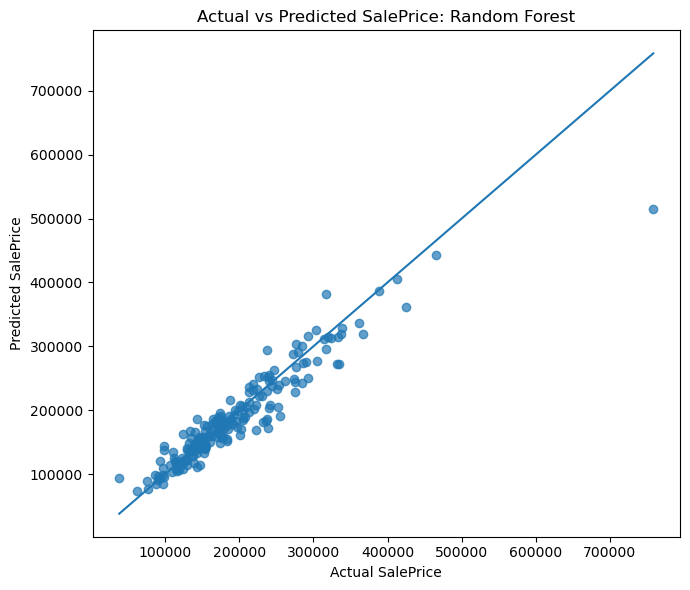

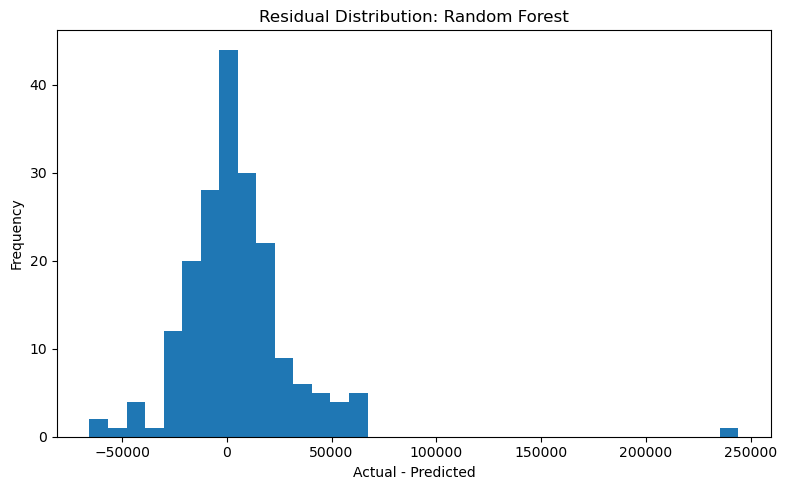

In [18]:
best_pred_log = best_model_info["test_predictions_log"]
actual_prices = np.expm1(y_test_log)
predicted_prices = np.expm1(best_pred_log)

prediction_compare = pd.DataFrame({
    "ActualPrice": actual_prices,
    "PredictedPrice": predicted_prices,
    "AbsoluteError": np.abs(actual_prices - predicted_prices)
}).sort_values("AbsoluteError", ascending=False)

display(prediction_compare.head(10))

plt.figure(figsize=(7, 6))
plt.scatter(actual_prices, predicted_prices, alpha=0.7)
min_value = min(actual_prices.min(), predicted_prices.min())
max_value = max(actual_prices.max(), predicted_prices.max())
plt.plot([min_value, max_value], [min_value, max_value])
plt.title(f"Actual vs Predicted SalePrice: {best_model_name}")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.tight_layout()
plt.show()

residuals = actual_prices - predicted_prices

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=35)
plt.title(f"Residual Distribution: {best_model_name}")
plt.xlabel("Actual - Predicted")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Business Insights

Based on the analysis, features like overall quality, living area, garage area, and basement area are important for property price.  
Sellers can focus on improving these parts to increase property value.

## Feature Importance Analysis

For tree-based models, we use `feature_importances_`.  
For linear models, we use the absolute size of coefficients.

,Feature,Importance
2,OverallQual,0.485370
30,TotalSF,0.276736
18,GarageArea,0.020896
17,GarageCars,0.016579
27,PropertyAge,0.013696
1,LotArea,0.012856
31,TotalBath,0.012340
7,GrLivArea,0.011176
4,YearBuilt,0.010007
3,OverallCond,0.009026


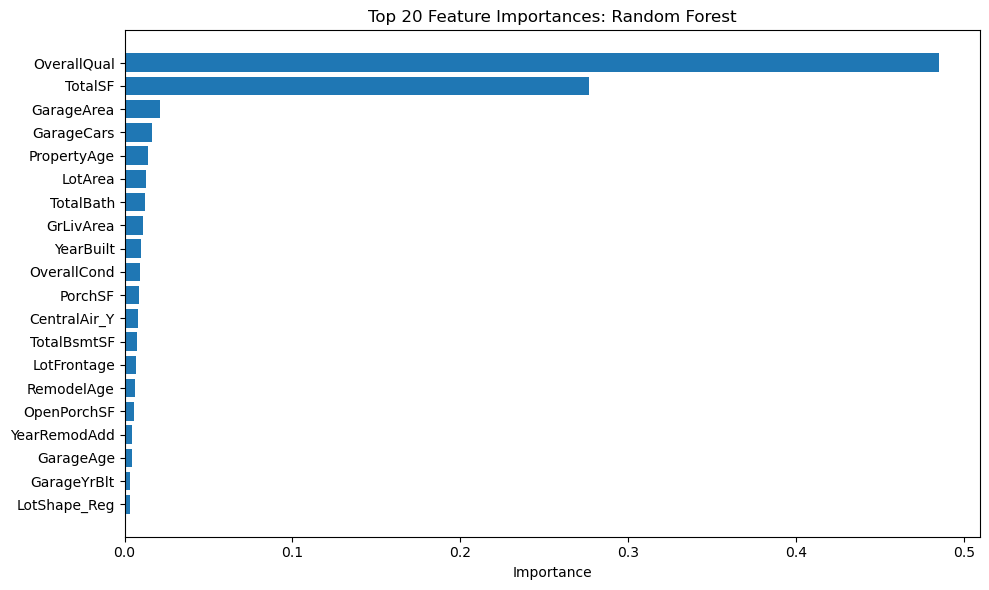

In [19]:
def get_feature_importance(model_name, model_info):
    model = model_info["model"]

    if hasattr(model, "feature_importances_"):
        importance_values = model.feature_importances_
    elif hasattr(model, "coef_"):
        importance_values = np.abs(model.coef_)
    else:
        raise ValueError("This model does not expose feature importance or coefficients.")

    return (
        pd.DataFrame({
            "Feature": X_train.columns,
            "Importance": importance_values
        })
        .sort_values("Importance", ascending=False)
        .head(20)
    )

importance_df = get_feature_importance(best_model_name, best_model_info)
display(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"].iloc[::-1], importance_df["Importance"].iloc[::-1])
plt.title(f"Top 20 Feature Importances: {best_model_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Business Recommendations

Based on the expected feature importance pattern in property price models:

1. **Overall material and finish quality is a major price driver.**  
   Sellers should prioritize visible quality improvements such as kitchen, exterior, and finishing upgrades.

2. **Living area and total square footage strongly influence price.**  
   Larger usable spaces such as above-ground living area and basement area generally support higher valuation.

3. **Garage capacity and garage area matter.**  
   Properties with larger or higher-quality garages may attract better buyer interest.

4. **Age and remodeling history affect perceived value.**  
   Newer homes or recently remodeled homes can command better prices, especially when quality ratings are high.

5. **Neighborhood and property condition should be considered together.**  
   Location-based dummy variables and quality ratings help capture market preference differences.

## Model Limitations and Future Work

**Limitations**

- The model is trained on historical data, so it may not fully capture current market shifts.
- External factors such as interest rates, local demand, school ratings, and nearby infrastructure are not included.
- Some high-value or unusual properties may still be difficult to predict accurately.
- Dummy encoding increases feature count, which can make interpretation harder.

**Future Work**

- Add current market indicators and location-based external data.
- Try advanced algorithms such as XGBoost, LightGBM, or CatBoost.
- Use nested cross-validation for stronger model selection.
- Build a simple prediction app where users can enter property details and estimate price.

# Final Conclusion

This project successfully applies a complete supervised machine learning workflow for property price prediction:

- Explored the dataset and target variable.
- Treated missing values based on feature meaning.
- Handled outliers using percentile capping.
- Created meaningful property-level features.
- Applied log transformation to the target variable.
- Encoded categorical variables using dummy variables.
- Compared multiple regression models.
- Evaluated the final model using RMSE, MAE, R², and RMSLE.
- Interpreted feature importance to produce business recommendations.

The final selected model can help sellers, buyers, and investors estimate property prices more objectively using property characteristics.

In this project, I cleaned the data, explored important features, built regression models, and evaluated their performance.  
The final model can help estimate property prices based on different property features.